In [ ]:
simport pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("PS_20174392719_1491204439457_log.csv")

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1832395,163,CASH_OUT,176340.89,C1208701261,0.0,0.0,C928176541,1527903.08,1803906.61,0.0,0.0
1832396,163,CASH_OUT,233050.27,C255820265,0.0,0.0,C763839065,1498605.70,1731655.96,0.0,0.0
1832397,163,CASH_OUT,21918.51,C1264461300,0.0,0.0,C482916346,1040374.93,1062293.44,0.0,0.0
1832398,163,CASH_OUT,53230.65,C113245234,0.0,0.0,C2014793134,792609.66,845840.32,0.0,0.0
1832399,163,CASH_OUT,85734.18,C346834065,0.0,0.0,C17847291,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(1832400, 11)

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1832400 entries, 0 to 1832399
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 153.8+ MB


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(1832399, 11)

In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
df["isFraud"].value_counts()

,count
isFraud,
0.0,1830531
1.0,1868


In [ ]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0.0,1832399


In [ ]:
df["type"].value_counts()

,count
type,
CASH_OUT,657123
PAYMENT,608174
CASH_IN,403134
TRANSFER,151974
DEBIT,11994


step: represents a unit of time where 1 step equals 1 hour
type: type of online transaction
amount: the amount of the transaction
nameOrig: customer starting the transaction
oldbalanceOrg: balance before the transaction
newbalanceOrig: balance after the transaction
nameDest: recipient of the transaction
oldbalanceDest: initial balance of recipient before the transaction
newbalanceDest: the new balance of recipient after the transaction
isFraud: fraud transaction

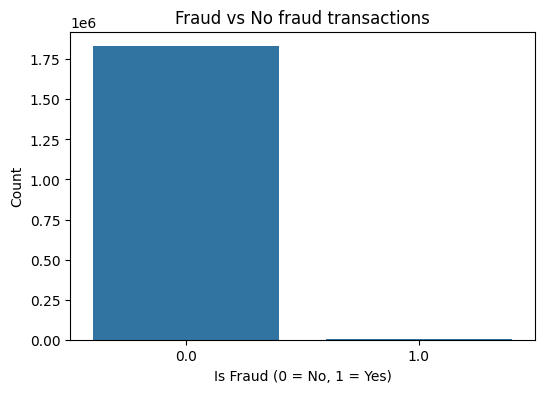

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="isFraud")
plt.title("Fraud vs No fraud transactions")
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel("Count")
plt.show()

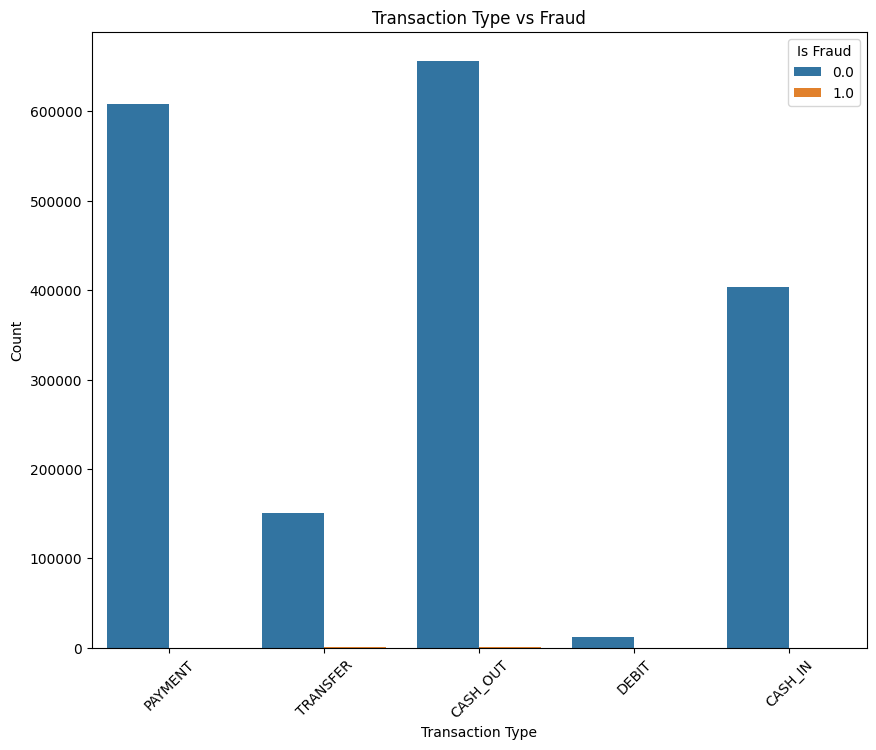

In [ ]:
#Fraud distribution by transaction type
plt.figure(figsize=(10,8))
sns.countplot(x='type', hue='isFraud', data=df)

plt.title('Transaction Type vs Fraud')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Is Fraud')
plt.show()

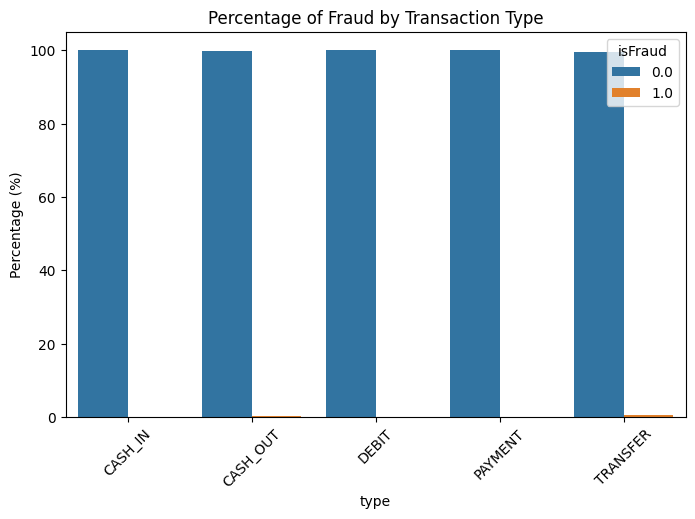

In [ ]:
#Percentage based visualisation
fraud_type_percent = (
    df.groupby('type')['isFraud']
      .value_counts(normalize=True)
      .rename('percentage')
      .mul(100)
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(x='type', y='percentage', hue='isFraud', data=fraud_type_percent)

plt.title('Percentage of Fraud by Transaction Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.show()

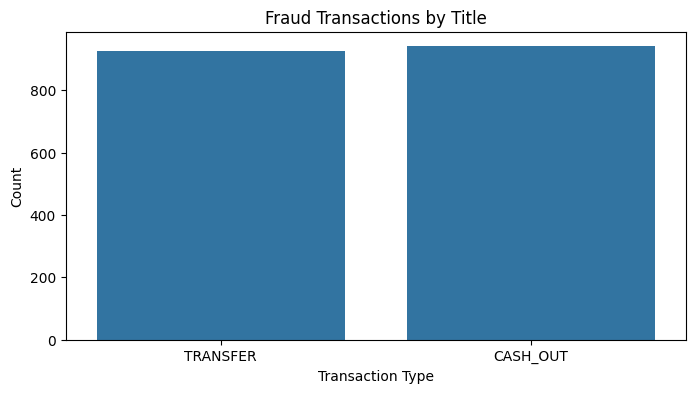

In [ ]:
#Only fraud transactions to see pattern clearly
fraud_only=df[df["isFraud"]==1]
plt.figure(figsize=(8,4))
sns.countplot(data=fraud_only,x="type")
plt.title("Fraud Transactions by Title")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

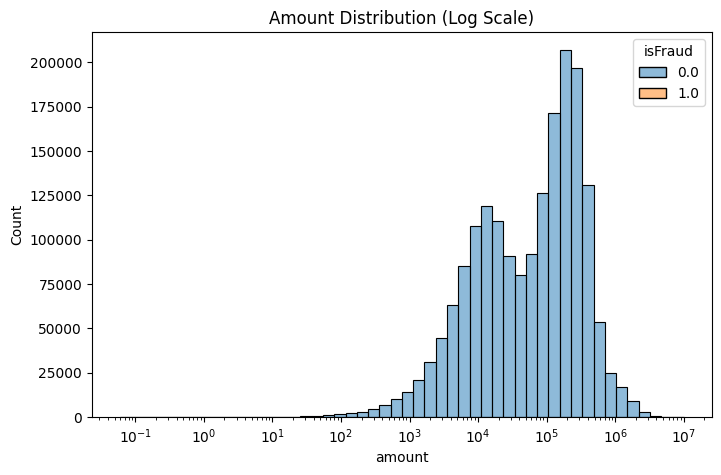

In [ ]:
#Distribution of amount
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='amount', hue='isFraud', bins=50, log_scale=True)
plt.title('Amount Distribution (Log Scale)')
plt.show()

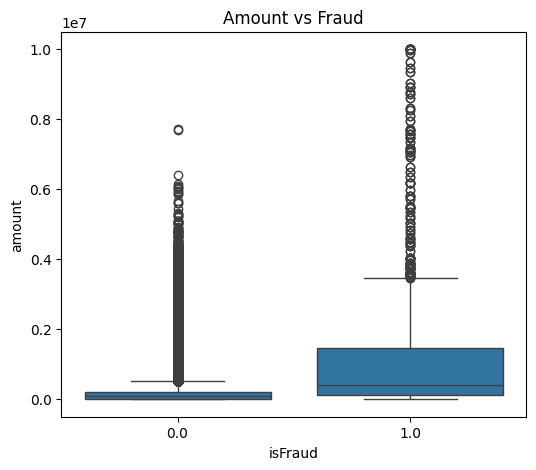

In [ ]:
#Boxplot
plt.figure(figsize=(6,5))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title('Amount vs Fraud')
plt.show()

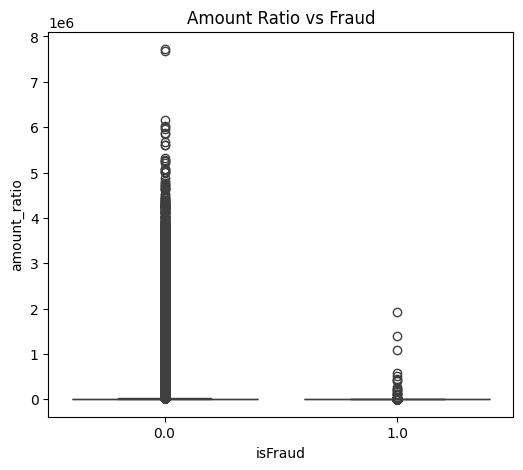

In [ ]:
#Amount ratio
df['amount_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

plt.figure(figsize=(6,5))
sns.boxplot(x='isFraud', y='amount_ratio', data=df)
plt.title('Amount Ratio vs Fraud')
plt.show()

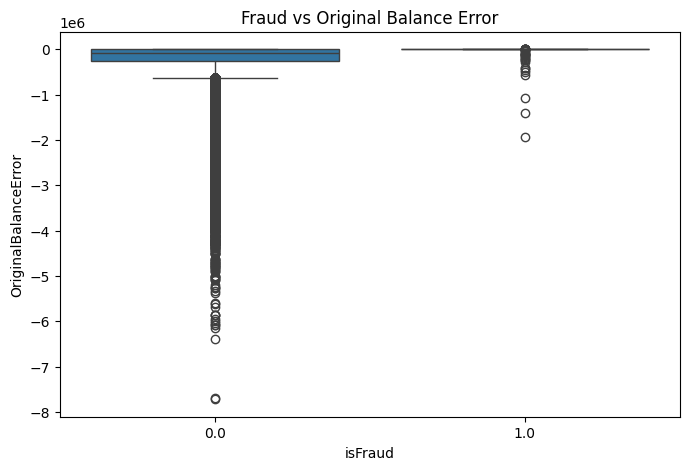

In [ ]:
#Balance Inconsistancies
#Original Balance Error
df["OriginalBalanceError"]=df["oldbalanceOrg"]-df["amount"]-df["newbalanceOrig"]
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="isFraud",y="OriginalBalanceError")
plt.title("Fraud vs Original Balance Error")
plt.show()

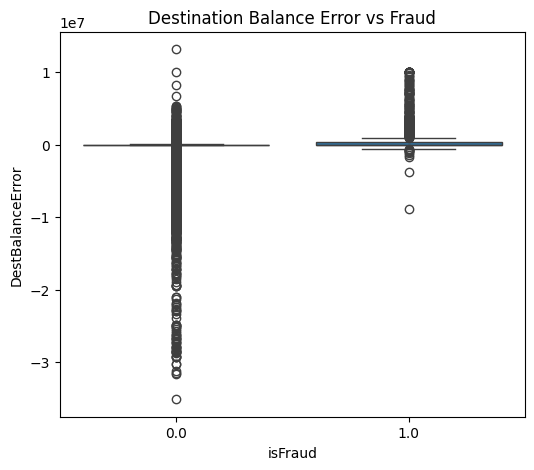

In [ ]:
#Destination Balance Error
df['DestBalanceError'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

plt.figure(figsize=(6,5))
sns.boxplot(x='isFraud', y='DestBalanceError', data=df)
plt.title('Destination Balance Error vs Fraud')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


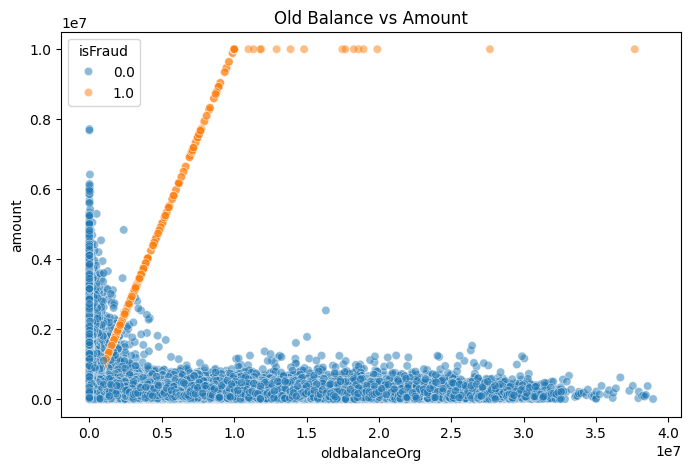

In [ ]:
#Basic Anomaly Visualisation
plt.figure(figsize=(8,5))
sns.scatterplot(x="oldbalanceOrg",y="amount",hue="isFraud",data=df,alpha=0.5)
plt.title("Old Balance vs Amount")
plt.show()

In [ ]:
#Feature Engineering
df['amount_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

df['OriginalBalanceWError'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']

df['DestBalanceError'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

df['IsFullTransfer'] = (df['newbalanceOrig'] == 0).astype(int)

In [ ]:
df = df.drop(['nameOrig', 'nameDest'], axis=1)

In [ ]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_ratio,OriginalBalanceError,DestBalanceError,OriginalBalanceWError,IsFullTransfer
0,1,PAYMENT,9839.64,170136.0,160296.36,0.00,0.00,0.0,0.0,0.057834,0.00,9839.64,0.00,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.00,0.00,0.0,0.0,0.087731,0.00,1864.28,0.00,0
2,1,TRANSFER,181.00,181.0,0.00,0.00,0.00,1.0,0.0,0.994505,0.00,181.00,0.00,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.00,0.00,1.0,0.0,0.994505,0.00,21363.00,0.00,1
4,1,PAYMENT,11668.14,41554.0,29885.86,0.00,0.00,0.0,0.0,0.280788,0.00,11668.14,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1832394,163,CASH_OUT,334218.89,0.0,0.00,495673.31,829892.19,0.0,0.0,334218.890000,-334218.89,0.01,-334218.89,1
1832395,163,CASH_OUT,176340.89,0.0,0.00,1527903.08,1803906.61,0.0,0.0,176340.890000,-176340.89,-99662.64,-176340.89,1
1832396,163,CASH_OUT,233050.27,0.0,0.00,1498605.70,1731655.96,0.0,0.0,233050.270000,-233050.27,0.01,-233050.27,1
1832397,163,CASH_OUT,21918.51,0.0,0.00,1040374.93,1062293.44,0.0,0.0,21918.510000,-21918.51,0.00,-21918.51,1


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [ ]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_ratio,OriginalBalanceError,DestBalanceError,OriginalBalanceWError,IsFullTransfer
0,1,3,9839.64,170136.0,160296.36,0.00,0.00,0.0,0.0,0.057834,0.00,9839.64,0.00,0
1,1,3,1864.28,21249.0,19384.72,0.00,0.00,0.0,0.0,0.087731,0.00,1864.28,0.00,0
2,1,4,181.00,181.0,0.00,0.00,0.00,1.0,0.0,0.994505,0.00,181.00,0.00,1
3,1,1,181.00,181.0,0.00,21182.00,0.00,1.0,0.0,0.994505,0.00,21363.00,0.00,1
4,1,3,11668.14,41554.0,29885.86,0.00,0.00,0.0,0.0,0.280788,0.00,11668.14,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1832394,163,1,334218.89,0.0,0.00,495673.31,829892.19,0.0,0.0,334218.890000,-334218.89,0.01,-334218.89,1
1832395,163,1,176340.89,0.0,0.00,1527903.08,1803906.61,0.0,0.0,176340.890000,-176340.89,-99662.64,-176340.89,1
1832396,163,1,233050.27,0.0,0.00,1498605.70,1731655.96,0.0,0.0,233050.270000,-233050.27,0.01,-233050.27,1
1832397,163,1,21918.51,0.0,0.00,1040374.93,1062293.44,0.0,0.0,21918.510000,-21918.51,0.00,-21918.51,1


In [ ]:
y=df["isFraud"]
x=df.drop("isFraud",axis=1)

In [ ]:
x

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,amount_ratio,OriginalBalanceError,DestBalanceError,OriginalBalanceWError,IsFullTransfer
0,1,3,9839.64,170136.0,160296.36,0.00,0.00,0.0,0.057834,0.00,9839.64,0.00,0
1,1,3,1864.28,21249.0,19384.72,0.00,0.00,0.0,0.087731,0.00,1864.28,0.00,0
2,1,4,181.00,181.0,0.00,0.00,0.00,0.0,0.994505,0.00,181.00,0.00,1
3,1,1,181.00,181.0,0.00,21182.00,0.00,0.0,0.994505,0.00,21363.00,0.00,1
4,1,3,11668.14,41554.0,29885.86,0.00,0.00,0.0,0.280788,0.00,11668.14,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1832394,163,1,334218.89,0.0,0.00,495673.31,829892.19,0.0,334218.890000,-334218.89,0.01,-334218.89,1
1832395,163,1,176340.89,0.0,0.00,1527903.08,1803906.61,0.0,176340.890000,-176340.89,-99662.64,-176340.89,1
1832396,163,1,233050.27,0.0,0.00,1498605.70,1731655.96,0.0,233050.270000,-233050.27,0.01,-233050.27,1
1832397,163,1,21918.51,0.0,0.00,1040374.93,1062293.44,0.0,21918.510000,-21918.51,0.00,-21918.51,1


In [ ]:
x=x.drop("isFlaggedFraud", axis=1)

In [ ]:
y

,isFraud
0,0.0
1,0.0
2,1.0
3,1.0
4,0.0
...,...
1832394,0.0
1832395,0.0
1832396,0.0
1832397,0.0


In [ ]:
x

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,amount_ratio,OriginalBalanceError,DestBalanceError,OriginalBalanceWError,IsFullTransfer
0,1,3,9839.64,170136.0,160296.36,0.00,0.00,0.057834,0.00,9839.64,0.00,0
1,1,3,1864.28,21249.0,19384.72,0.00,0.00,0.087731,0.00,1864.28,0.00,0
2,1,4,181.00,181.0,0.00,0.00,0.00,0.994505,0.00,181.00,0.00,1
3,1,1,181.00,181.0,0.00,21182.00,0.00,0.994505,0.00,21363.00,0.00,1
4,1,3,11668.14,41554.0,29885.86,0.00,0.00,0.280788,0.00,11668.14,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1832394,163,1,334218.89,0.0,0.00,495673.31,829892.19,334218.890000,-334218.89,0.01,-334218.89,1
1832395,163,1,176340.89,0.0,0.00,1527903.08,1803906.61,176340.890000,-176340.89,-99662.64,-176340.89,1
1832396,163,1,233050.27,0.0,0.00,1498605.70,1731655.96,233050.270000,-233050.27,0.01,-233050.27,1
1832397,163,1,21918.51,0.0,0.00,1040374.93,1062293.44,21918.510000,-21918.51,0.00,-21918.51,1


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=sc.fit_transform(x)

In [ ]:
x

array([[-1.2725573 ,  0.96643891, -0.56772468, ..., -0.08556852,
         0.64262522, -1.13564717],
       [-1.2725573 ,  0.96643891, -0.59746742, ..., -0.10749663,
         0.64262522, -1.13564717],
       [-1.2725573 ,  1.70937026, -0.60374492, ..., -0.11212478,
         0.64262522,  0.88055518],
       ...,
       [ 1.43836232, -0.5194238 ,  0.264701  , ..., -0.11262241,
        -0.17441341,  0.88055518],
       [ 1.43836232, -0.5194238 , -0.52267861, ..., -0.11262244,
         0.56578228,  0.88055518],
       [ 1.43836232, -0.5194238 , -0.40590537, ..., -0.11262246,
         0.4560067 ,  0.88055518]])

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # handles imbalance
    random_state=42
)

rfc.fit(xtrain,ytrain)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

ypred = rfc.predict(xtest)
print(confusion_matrix(ytest, ypred))
print(classification_report(ytest, ypred))

[[366106      0]
 [     6    368]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    366106
         1.0       1.00      0.98      0.99       374

    accuracy                           1.00    366480
   macro avg       1.00      0.99      1.00    366480
weighted avg       1.00      1.00      1.00    366480



In [ ]:
#ROC-AUC
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve

roc_auc_score(ytest, rfc.predict_proba(xtest)[:,1])

np.float64(0.9919730883002208)

In [ ]:
#PR-AUC
from sklearn.metrics import precision_recall_curve, auc

yscores = rfc.predict_proba(xtest)[:,1]

precision, recall, thresholds = precision_recall_curve(ytest, yscores)

pr_auc = auc(recall, precision)
print("PR AUC:", pr_auc)

PR AUC: 0.9887264885558877


In [ ]:
#Feature Importance Analysis
feature_importance = rfc.feature_importances_

# Get feature names from the 'x' DataFrame before scaling and converting to numpy array
# Reconstruct feature names from the operations that created 'x'
feature_names = df.drop("isFraud", axis=1).drop("isFlaggedFraud", axis=1).columns

# Create a Pandas Series for easier sorting and viewing
importance_series = pd.Series(feature_importance, index=feature_names)

importance_series.sort_values(ascending=False).head(10)

,0
amount_ratio,0.203526
OriginalBalanceError,0.202759
OriginalBalanceWError,0.200177
newbalanceOrig,0.128193
IsFullTransfer,0.127273
oldbalanceOrg,0.042617
type,0.037433
amount,0.026903
DestBalanceError,0.014981
oldbalanceDest,0.007807


In [ ]:
#Threshold Tuning
from sklearn.metrics import precision_recall_curve
precision,recall,thresholds=precision_recall_curve(ytest,yscores)
f1_scores=(2*precision*recall)/(precision+recall+1e-10)
best_threshold=thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_threshold)

Best Threshold: 0.89


In [ ]:
#Compare threshold
from sklearn.metrics import classification_report

# Default 0.5
ypred_05 = (yscores >= 0.5).astype(int)
print("Threshold 0.5")
print(classification_report(ytest, ypred_05))

# Best 0.89
y_pred_089 = (yscores >= 0.89).astype(int)
print("Threshold 0.89")
print(classification_report(ytest, y_pred_089))

Threshold 0.5
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    366106
         1.0       1.00      0.98      0.99       374

    accuracy                           1.00    366480
   macro avg       1.00      0.99      1.00    366480
weighted avg       1.00      1.00      1.00    366480

Threshold 0.89
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    366106
         1.0       1.00      0.98      0.99       374

    accuracy                           1.00    366480
   macro avg       1.00      0.99      1.00    366480
weighted avg       1.00      1.00      1.00    366480



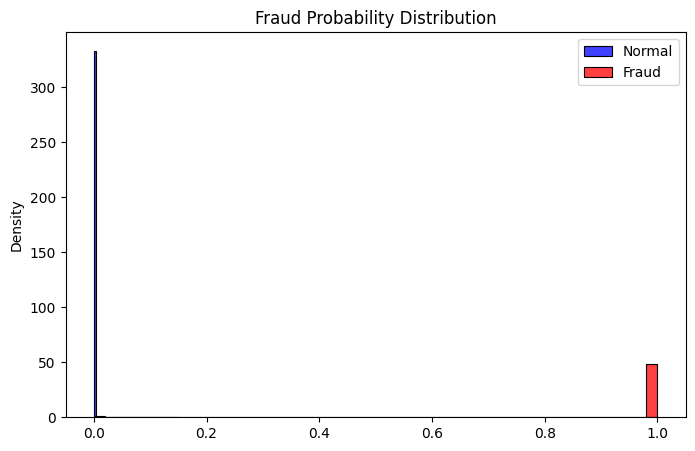

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(yscores[ytest == 0], color='blue', label='Normal', bins=50, stat='density')
sns.histplot(yscores[ytest == 1], color='red', label='Fraud', bins=50, stat='density')

plt.legend()
plt.title("Fraud Probability Distribution")
plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.001,   # approximate fraud rate
    random_state=42
)

iso.fit(x)

# Predict
df['anomaly'] = iso.predict(x)

# Convert output
df['anomaly'] = df['anomaly'].map({1:0, -1:1})

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(df['isFraud'], df['anomaly']))
print(classification_report(df['isFraud'], df['anomaly']))

roc = roc_auc_score(df['isFraud'], df['anomaly'])
print("ROC-AUC:", roc)

[[1828698    1833]
 [   1868       0]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1830531
         1.0       0.00      0.00      0.00      1868

    accuracy                           1.00   1832399
   macro avg       0.50      0.50      0.50   1832399
weighted avg       1.00      1.00      1.00   1832399

ROC-AUC: 0.499499325605521


In [ ]:
df['anomaly_score'] = -iso.decision_function(x)

from sklearn.metrics import roc_auc_score
roc_auc_score(df['isFraud'], df['anomaly_score'])

np.float64(0.74576001105152)

In [ ]:
iso = IsolationForest(
    n_estimators=300,
    contamination=0.005,   # increase
    max_samples='auto',
    random_state=42
)
iso.fit(x)

IsolationForest(contamination=0.005, n_estimators=300, random_state=42)

In [ ]:
df['anomaly_score'] = -iso.decision_function(x)

from sklearn.metrics import roc_auc_score
roc_auc_score(df['isFraud'], df['anomaly_score'])

np.float64(0.7651278077446074)

<Figure size 640x480 with 0 Axes>

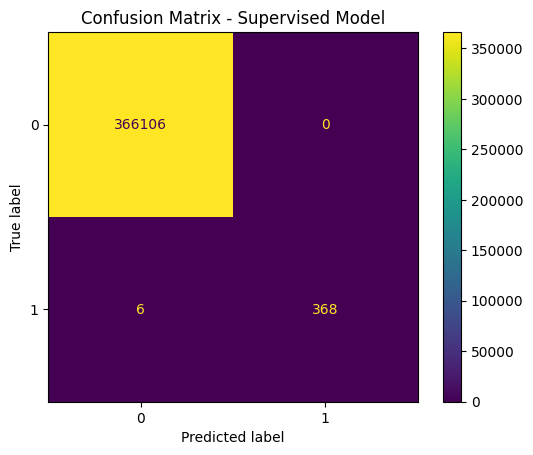

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(ytest, ypred)

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Supervised Model")
plt.show()

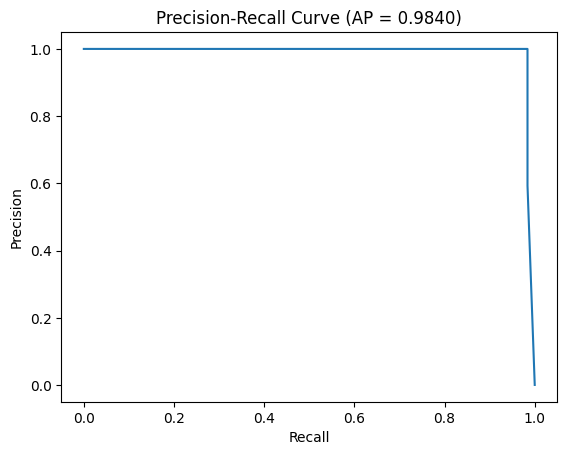

Average Precision (PR-AUC): 0.9839735912225223


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(ytest, yscores)
ap_score = average_precision_score(ytest, yscores)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap_score:.4f})")
plt.show()

print("Average Precision (PR-AUC):", ap_score)

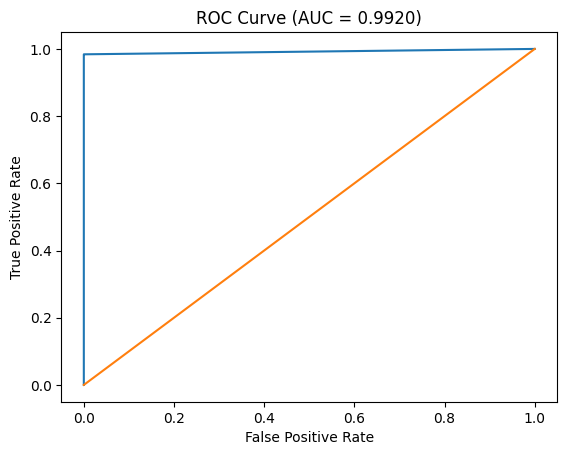

ROC-AUC: 0.9919730883002208


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(ytest, yscores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

print("ROC-AUC:", roc_auc)